In [27]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

mdb_path = r"C:\Users\Jouke\Desktop\emergo_dataset\DemoDataBetsyBike.mdb"

conn_str = (
    r"Driver={Microsoft Access Driver (*.mdb, *.accdb)};"
    fr"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

In [28]:
cursor = conn.cursor()
tables = [row.table_name for row in cursor.tables(tableType='TABLE')]
print("Gevonden tabellen:", tables)

Gevonden tabellen: ['Address', 'Customer', 'Employee', 'Person', 'Product', 'ProductCategory', 'ProductModel', 'ProductSubcategory', 'ProductVendor', 'SalesOrderDetail', 'SalesOrderHeader', 'SalesTerritory', 'SalesTerritoryHistory', 'Store', 'Vendor']


In [29]:
dfs = {t: pd.read_sql(f"SELECT * FROM [{t}]", conn) for t in tables}
#conn.close()

C:\Users\Jouke\AppData\Local\Temp\ipykernel_24832\165661988.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs = {t: pd.read_sql(f"SELECT * FROM [{t}]", conn) for t in tables}


In [30]:
dfs.keys()

dict_keys(['Address', 'Customer', 'Employee', 'Person', 'Product', 'ProductCategory', 'ProductModel', 'ProductSubcategory', 'ProductVendor', 'SalesOrderDetail', 'SalesOrderHeader', 'SalesTerritory', 'SalesTerritoryHistory', 'Store', 'Vendor'])

In [31]:
df_sales = dfs['SalesOrderDetail'].copy()
df_product = dfs['Product'].copy()
df_subcat = dfs['ProductSubcategory'].copy()
df_category = dfs['ProductCategory'].copy()

In [32]:
df_sales['Revenue'] = (
    df_sales['OrderQty'].astype(float)
    * df_sales['UnitPrice'].astype(float)
    * (1 - df_sales['UnitPriceDiscount'].astype(float))
)

In [33]:
product_dim = (
    df_product[['ProductID', 'Name', 'ProductSubcategoryID']]
    .drop_duplicates(subset=['ProductID'])
    .rename(columns={'Name': 'ProductName'})
)
subcat_dim = (
    df_subcat[['ProductSubcategoryID', 'ProductCategoryID']]
    .drop_duplicates(subset=['ProductSubcategoryID'])
)
category_dim = (
    df_category[['ProductCategoryID', 'Name']]
    .drop_duplicates(subset=['ProductCategoryID'])
    .rename(columns={'Name': 'Category'})
)

In [34]:
sales_with_product = (
    df_sales
    .merge(product_dim, on='ProductID', how='left', validate='m:1')
    .merge(subcat_dim, on='ProductSubcategoryID', how='left', validate='m:1')
    .merge(category_dim, on='ProductCategoryID', how='left', validate='m:1')
)

In [35]:
print("Aantal regels:", len(sales_with_product))
print("Totaalomzet: €", round(sales_with_product['Revenue'].sum(), 2))

Aantal regels: 119108
Totaalomzet: € 109795540.77


In [37]:
top_x = 10
top_products = (
    sales_with_product.groupby(['ProductID', 'ProductName', 'Category'], as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
    .head(top_x)
)

print("\nTop 10 producten:")
print(top_products)


Top 10 producten:
    ProductID              ProductName Category       Revenue
65      782.0   Mountain-200 Black, 38    Bikes  4.400593e+06
66      783.0   Mountain-200 Black, 42    Bikes  4.009495e+06
62      779.0  Mountain-200 Silver, 38    Bikes  3.693678e+06
63      780.0  Mountain-200 Silver, 42    Bikes  3.438479e+06
64      781.0  Mountain-200 Silver, 46    Bikes  3.434257e+06
67      784.0   Mountain-200 Black, 46    Bikes  3.309673e+06
76      793.0       Road-250 Black, 44    Bikes  2.516857e+06
77      794.0       Road-250 Black, 48    Bikes  2.347656e+06
78      795.0       Road-250 Black, 52    Bikes  2.012448e+06
36      753.0         Road-150 Red, 56    Bikes  1.847819e+06


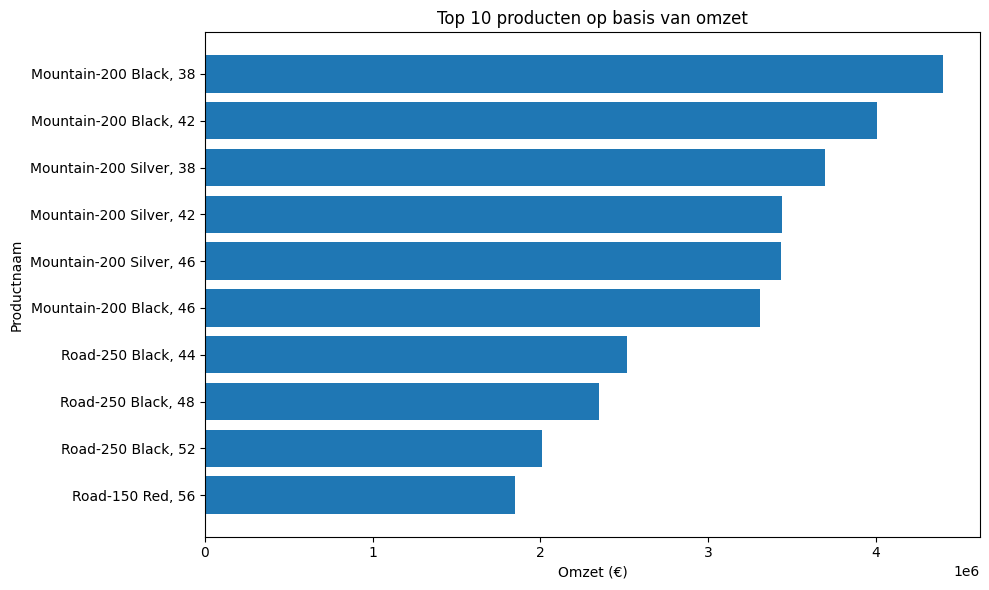

In [38]:
plt.figure(figsize=(10,6))
plt.barh(top_products['ProductName'][::-1], top_products['Revenue'][::-1])
plt.title(f"Top {top_x} producten op basis van omzet")
plt.xlabel("Omzet (€)")
plt.ylabel("Productnaam")
plt.tight_layout()
plt.show()